<a href="https://colab.research.google.com/github/lauraceciliadiazdavila/IA-LIDeSIA-Dpto-Computacion/blob/main/18_Forecasting/2026_02_Mauro_series_temporales_y_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

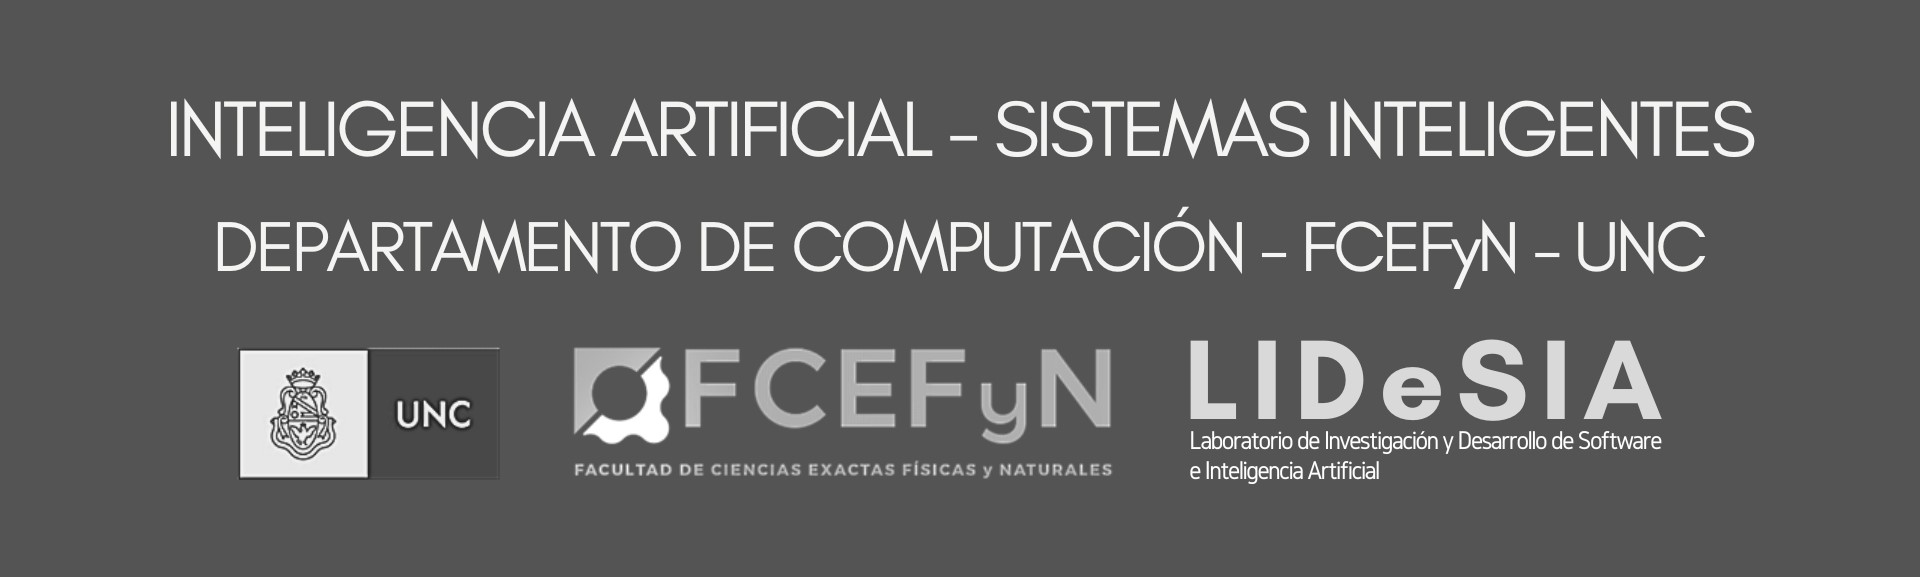

---

FCEFyN - UNC - Cátedra de Inteligencia Artificial - Año 2026 Segundo Semestre

---

*   Autor: Mgtr. Ing. Mauro Furer (FCEFyN)

*   Directora: Dra. Laura Cecilia Diaz Davila (LIDeSIA - FCEFyN)

---

# Series Temporales y Forecasting

## ¿Qué es una serie temporal? ¿Qué es *forecasting*?

Una **serie temporal** es una secuencia de observaciones **ordenadas en el tiempo**,
medidas a intervalos regulares: ventas diarias, temperatura por hora, pasajeros por mes.

$$y_1, y_2, \ldots, y_T$$

Lo que la distingue de los datasets que se vieron hasta ahora es:

> **El orden importa.** Las observaciones *no son independientes*: lo que pasa hoy
> depende de lo que pasó ayer. No podemos mezclar las filas.

**Forecasting** es estimar valores *futuros* usando la historia de la serie:

$$\hat{y}_{T+h \mid T} \;=\; \text{predicción de } y_{T+h} \text{ dado } y_1,\ldots,y_T$$

 El sombrero indica estimación y la barra vertical, la información disponible y $h$ es el **horizonte de predicción**.

## Se cargan los elementos basicos para la presentacion de los ejemplos

In [38]:
# modulos que voy a necesitar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paleta y estilo para las figuras
VIOLETA, ROSA = "#8a63c9", "#d0517e"
AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
TINTA, TINTA2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRILLA, EJE, FONDO = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": FONDO, "axes.facecolor": FONDO, "savefig.facecolor": FONDO,
    "axes.edgecolor": EJE, "axes.labelcolor": TINTA2, "axes.grid": True,
    "grid.color": GRILLA, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": TINTA,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.dpi": 110, "legend.frameon": False,
})
# Directorios con las figuras del notebook
FIGDIR = Path("/content/figuras"); FIGDIR.mkdir(exist_ok=True)

## Vamos a ver tres series de ejemplos

Tres series reales, de tres fenómenos completamente distintos.

### Los datos

- **A · Pasajeros aéreos mensuales, 1949–1960** — el clásico *AirPassengers* de
  Box & Jenkins (1976); viene incluido en R.
- **B · Temperatura mínima diaria en Melbourne, 1981–1990** — Australian Bureau of Meteorology.
- **C · Manchas solares por año, 1700–2008** — [NOAA National Geophysical Data
  Center](https://www.ngdc.noaa.gov/stp/solar/solarda3.html), distribuido con `statsmodels`.

In [39]:
!mkdir -p datos
!curl -sL -o /content/datos/airline-passengers.csv     https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv
!curl -sL -o /content/datos/daily-min-temperatures.csv https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv
!curl -sL -o /content/datos/manchas-solares.csv        https://raw.githubusercontent.com/statsmodels/statsmodels/main/statsmodels/datasets/sunspots/sunspots.csv
!ls -lh /content/datos/airline-passengers.csv datos/daily-min-temperatures.csv datos/manchas-solares.csv

-rw-r--r-- 1 root root 2.2K Sep  2 13:39 /content/datos/airline-passengers.csv
-rw-r--r-- 1 root root  67K Sep  2 13:39 datos/daily-min-temperatures.csv
-rw-r--r-- 1 root root 2.9K Sep  2 13:39 datos/manchas-solares.csv


In [40]:
# Serie A: pasajeros mensuales de aerolíneas internacionales, 1949-1960 (AirPassengers)
a = pd.read_csv("/content/datos/airline-passengers.csv")
serie_a = pd.Series(a["Passengers"].to_numpy(),
                    index=pd.PeriodIndex(a["Month"], freq="M").to_timestamp())

# Serie B: temperatura mínima diaria en Melbourne, registro 1981-1990
b = pd.read_csv("/content/datos/daily-min-temperatures.csv", parse_dates=["Date"])
serie_b = pd.Series(b["Temp"].to_numpy(), index=b["Date"])

# Serie C: número anual de manchas solares, 1700-2008
c = pd.read_csv("/content/datos/manchas-solares.csv")
serie_c = pd.Series(c["SUNACTIVITY"].to_numpy(),
                    index=pd.to_datetime(c["YEAR"], format="%Y"))

SERIES = [("A — Pasajeros aéreos mensuales (miles)", serie_a),
          ("B — Temperatura mínima diaria en Melbourne (°C)", serie_b),
          ("C — Manchas solares por año", serie_c)]

for titulo, s in SERIES:
    print(f"{titulo:48s} {len(s):5d} obs.   {s.index.min():%Y-%m-%d} → {s.index.max():%Y-%m-%d}")

A — Pasajeros aéreos mensuales (miles)             144 obs.   1949-01-01 → 1960-12-01
B — Temperatura mínima diaria en Melbourne (°C)   3650 obs.   1981-01-01 → 1990-12-31
C — Manchas solares por año                        309 obs.   1700-01-01 → 2008-01-01


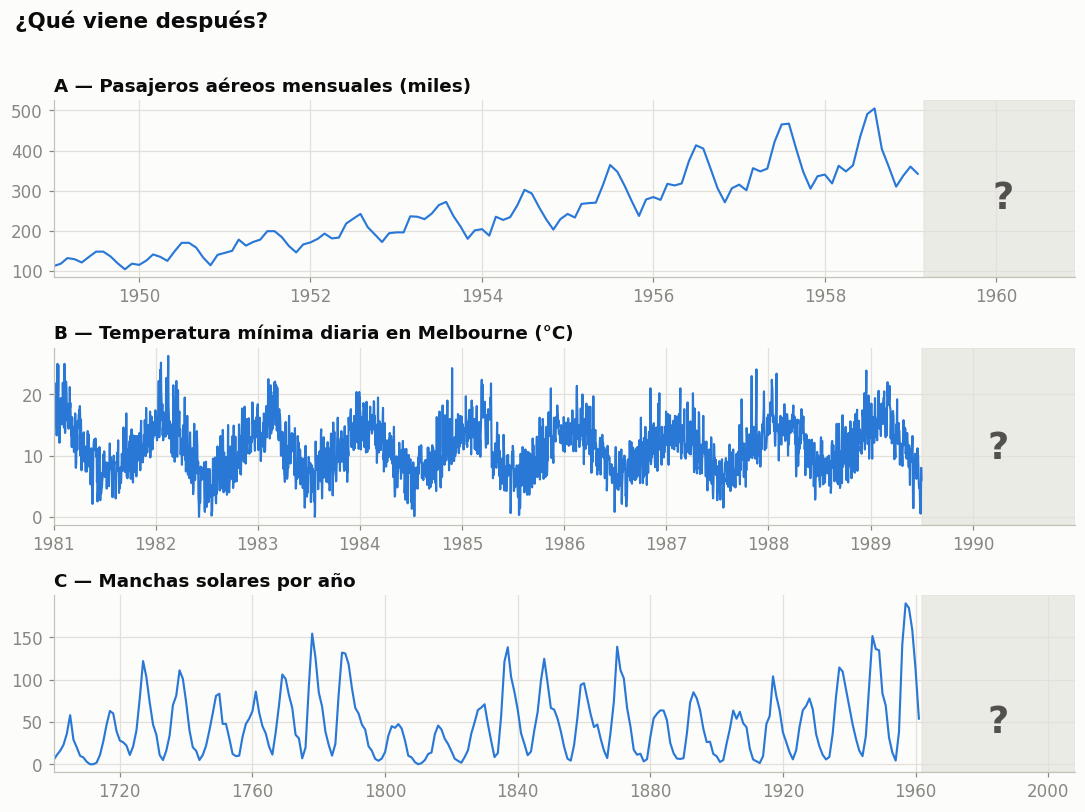

In [41]:
# Las tres series con el último 15% tapado: ¿qué viene después?
fig, axes = plt.subplots(3, 1, figsize=(10, 7.5))
for ax, (titulo, s) in zip(axes, SERIES):
    corte = int(len(s) * 0.85)
    ax.plot(s.index[:corte], s.iloc[:corte], color=AZUL, lw=1.4)
    ax.axvspan(s.index[corte], s.index[-1], color=GRILLA, alpha=0.6)   # la franja que tapa
    ax.text(s.index[(corte + len(s)) // 2], s.mean(), "?", fontsize=24,
            ha="center", va="center", color=TINTA2, fontweight="bold")
    ax.set_xlim(s.index[0], s.index[-1])
    ax.set_title(titulo, loc="left")
fig.suptitle("¿Qué viene después?", fontsize=14, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

### Podemos hacer una pregunta

Cada serie está cortada: **se ocultan los ultimos valores**.

> **¿Qué valor viene después, en el área gris? ¿Y cómo lo saben?**

Tomemos un momento por serie antes de seguir.

## Vamos a ponerle nombre a lo que se observa

Las respuestas que pueden aparecer ya son el vocabulario técnico. Solo hay que
traducirlas:

| Lo que dicen | El concepto |
|---|---|
| "valor parecido al ayer" | **lag** (retardo): el valor $y_{t-1}$, $y_{t-12}$, … |
| "mismo mes del año pasado" | **estacionalidad** |
| "viene subiendo y va a seguir subiendo" | **tendencia** |
| "sube y baja, pero no se ve claramente cuándo" | **ciclo** |
| "no se puede saber" | **ruido** |

Se definen los tres patrones:

- **Tendencia** (*trend*): "un incremento o decremento **de largo plazo** en los datos".
  No tiene por qué ser una línea recta.
- **Estacionalidad** (*seasonal*): la serie se ve afectada por factores estacionales
  —el mes, el día de la semana— y **siempre tiene una frecuencia fija y conocida**.
- **Ciclo** (*cyclic*): subidas y bajadas que **no son de frecuencia fija**; suelen durar
  más y tener amplitud más variable.

> Debemos tener cuidado con **Estacional ≠ cíclico.** Es una confusión común, pero debe distinguirse:
> si la frecuencia es **fija y conocida de antemano**, es estacionalidad; si **varía**, es un
> ciclo. Los ciclos son mucho más difíciles de predecir, porque no hay calendario al que
> anclarse.

### Aplicado a nuestras tres series

- **A · Pasajeros aéreos** — **tendencia** creciente **+ estacionalidad** anual: los picos de
  verano se repiten cada 12 meses, puntuales. Es la más predecible de las tres. Fíjense
  además en que la amplitud de los picos.

- **B · Temperatura de Melbourne** — **estacionalidad pura**, sin tendencia: el nivel medio de
  1990 es igual al de 1981. El calendario explica casi todo… *en promedio*. Pero miren el
  ruido diario: sabemos con certeza en qué estación estamos, y aun así el valor de un día
  puntual varía varios grados. **Estructura fuerte y ruido fuerte conviven.**

- **C · Manchas solares** — **ciclo**, no estacionalidad. Sube y baja de forma evidente, pero
  los máximos están separados por unos 11 años: a veces 9, a veces 13, y con alturas muy
  distintas. No hay ningún calendario que permita anticiparlos.

Las tres series muestran que **"predecir" no significa lo mismo en todos los casos**:

| Serie | ¿Qué tan predecible? | ¿Por qué? |
|---|---|---|
| A · Pasajeros | mucho | tendencia + calendario |
| B · Temperatura | el promedio sí, el día puntual no | calendario fuerte, ruido alto |
| C · Manchas solares | poco | hay estructura, pero sin calendario |


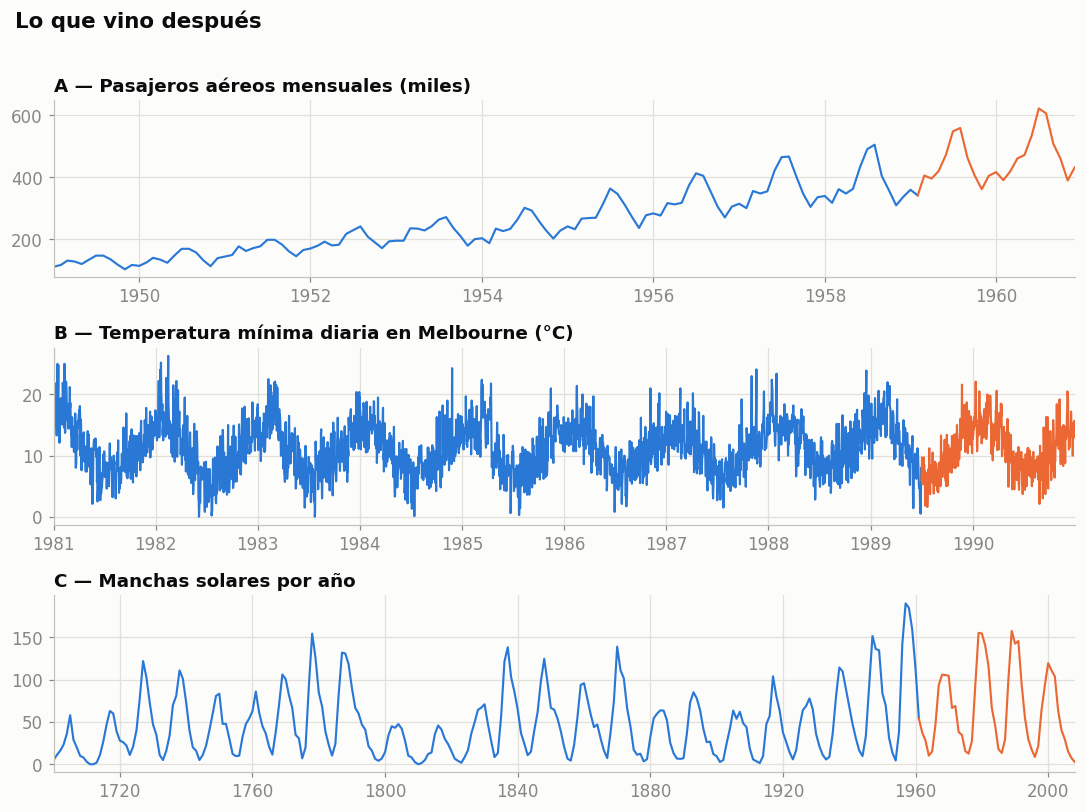

In [42]:
# Las tres series completas: lo que estaba tapado, en naranja
fig, axes = plt.subplots(3, 1, figsize=(10, 7.5))
for ax, (titulo, s) in zip(axes, SERIES):
    corte = int(len(s) * 0.85)
    ax.plot(s.index[:corte], s.iloc[:corte], color=AZUL, lw=1.4)
    ax.plot(s.index[corte-1:], s.iloc[corte-1:], color=NARANJA, lw=1.4)
    ax.set_xlim(s.index[0], s.index[-1])
    ax.set_title(titulo, loc="left")
fig.suptitle("Lo que vino después", fontsize=14, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

# Metricas

Vamos a necesitar medir el desempeño de los modelos de pronosticos sobre series de tiempo.

In [43]:
b = pd.read_csv("/content/datos/daily-min-temperatures.csv", parse_dates=["Date"])
temp = pd.Series(b["Temp"].to_numpy(), index=b["Date"])

datos = pd.DataFrame({"real": temp, "naive": temp.shift(1)}).dropna()
datos["error"] = datos["real"] - datos["naive"]
datos.head()

,real,naive,error
Date,,,
1981-01-02,17.9,20.7,-2.8
1981-01-03,18.8,17.9,0.9
1981-01-04,14.6,18.8,-4.2
1981-01-05,15.8,14.6,1.2
1981-01-06,15.8,15.8,0.0


## Definiciones

El **error de pronóstico** es la diferencia entre lo observado y lo predicho:

$$e_{T+h} = y_{T+h} - \hat{y}_{T+h\mid T}$$

- $y_{T+h}$ es **un solo valor**: la observación en el instante $T+h$.
- $\hat{y}_{T+h\mid T}$ es su predicción **usando solo información hasta $T$**.
- Por lo tanto $e_{T+h}$ también es **un único número**.

Todo pronóstico se hace *a una cierta distancia*, y esa distancia es el **horizonte $h$**.

> **$h=7$ NO es "siete días": es "el séptimo día".**
>
> | | Significa | Cuántos valores |
> |---|---|---|
> | $h=7$ | el **séptimo** día después del origen | **uno solo** |
> | $h = 1,2,\ldots,7$ | los **próximos siete** días | siete |
>
> Debemos tener la consideración que en la implementación en software suele significar lo otro: `forecast(h=7)` normalmente devuelve el
> **camino completo** de siete pasos.

Las métricas **promedian muchos de esos errores**. Lo primero que uno haría —promediarlos tal
cual— no funciona:

In [44]:
print(f"media del error: {datos['error'].mean():+.3f} °C")

media del error: -0.002 °C


Da casi cero, y eso **no** significa que el pronóstico sea bueno: los errores positivos y
negativos **se cancelan**. La media del error mide el **sesgo**, no la magnitud.
Para obtener la magnitud hay que sacarle el signo.

Con esa idea tenemos las siguientes métricas:

**Error absoluto medio**

$$\text{MAE} = \text{mean}(|e_t|) \qquad\qquad$$

**Raiz cuadrada del error cuadrático medio**

$$\text{RMSE} = \sqrt{\text{mean}(e_t^{\,2})}$$

In [45]:
def mae(real, pred):   return (real - pred).abs().mean()
def rmse(real, pred):  return np.sqrt(((real - pred) ** 2).mean())

print(f"MAE  = {mae(datos['real'], datos['naive']):.2f} °C")
print(f"RMSE = {rmse(datos['real'], datos['naive']):.2f} °C")

MAE  = 2.13 °C
RMSE = 2.73 °C


Las dos quedan **en las unidades de los datos**, la diferencia consiste en:

- Minimizar el **MAE** lleva a pronosticar la **mediana**.
- Minimizar el **RMSE** lleva a pronosticar la **media**, y castiga más los errores grandes.

**¿Por qué no el MSE?** Porque quedaría en **grados al cuadrado**, que es dificil de interpretar. Para elegir entre modelos da igual —el que minimiza el MSE es el mismo que minimiza el
RMSE— pero para *reportar* se usa el que se puede leer.

### Para comparar entre series distintas

MAE y RMSE están en °C: no sirven para comparar contra una serie de pasajeros o de ventas.
La idea intuitiva es pasar a porcentaje:

**Error porcentual absoluto medio**

$$\text{MAPE} = \text{mean}(|p_t|), \qquad p_t = 100\,e_t/y_t$$

In [46]:
mape = (100 * datos["error"] / datos["real"]).abs()
print(f"MAPE = {mape.mean()}")
print(f"\ndías con temperatura 0.0 °C: {(datos['real'] == 0).sum()}")

MAPE = inf

días con temperatura 0.0 °C: 2


**Infinito.** Hubo dos días de exactamente 0,0 °C y el MAPE divide por $y_t$: dos días entre
3.649 arruinaron la métrica completa.

Además hay otro problema, más de fondo: el MAPE **necesita que el cero signifique algo**, y el
0 °C es arbitrario. La misma serie medida en Kelvin daría un MAPE distinto. Para temperatura el
MAPE no tiene sentido, aunque no hubiera ningún cero.

Una alternativa mas robusta es el **MASE**: dividir el MAE por el error que comete el naive **sobre
el conjunto de entrenamiento**. Al ser un número fijo de la serie, permite comparar entre
series con unidades distintas.


## Resumen

| Métrica | Para qué | Límite |
|---|---|---|
| **MAE** | decidir en unidades reales | no compara entre series |
| **RMSE** | cuando los errores grandes duelen más | no compara entre series |
| **MASE** | comparar entre series y contra el naive | menos intuitiva |
| **MAPE** | comunicar el error porcentual cuando los valores son positivos y están alejados de cero | explota cerca de cero |

## ¿Qué significa predecir?

> 📖 Basado en **Hyndman & Athanasopoulos**, *Forecasting: Principles and Practice*,
> capítulo 1 ([otexts.com/fpppy](https://otexts.com/fpppy/)).

Ya sabemos medir el error. Falta la pregunta anterior: ¿qué hacemos *exactamente* cuando
predecimos?

**Predecir es estimar cómo va a continuar la secuencia de observaciones**, asumiendo que
la manera en que el entorno viene cambiando **va a seguir en el futuro**. No podemos ver
el futuro: solo podemos capturar los patrones genuinos de la historia — ciclos, tendencia,
persistencia — y extenderlos hacia adelante, sin replicar eventos del pasado que no van a
volver a ocurrir. Por eso el naive es un pronóstico legítimo: "mañana ≈ hoy" es ese
supuesto en su mínima expresión.

Y no todo es igual de predecible. La predictibilidad de un fenómeno depende de:

1. **cuánto entendemos los factores que contribuyen a él**;
2. **cuántos datos hay disponibles**;
3. **cuánto se parece el futuro al pasado**;
4. **si el pronóstico puede afectar aquello que se pronostica**.

La **demanda eléctrica** cumple las cuatro condiciones — se entienden sus causas
(temperatura, calendario), hay datos de sobra, los ciclos se repiten, y el pronóstico no
cambia el consumo — y por eso es altamente predecible. El **tipo de cambio**, en cambio,
cumple solo una (hay muchos datos): entendemos poco sus causas, el futuro puede no
parecerse al pasado, y un pronóstico difundido puede mover el precio y afectarse a sí
mismo. Predecirlo bien es muchísimo más difícil.

De acá sale una consecuencia práctica: si predecir es afirmar algo sobre **datos que
todavía no vimos**, evaluar un pronóstico exige imitar esa situación — esconder una parte
de la historia, pronosticarla como si no la conociéramos, y recién después comparar. Eso
—ni más ni menos— es el **train-test**.

### Los métodos estadísticos clásicos

Antes de los árboles y los *foundation models*, la estadística proporcionaba elementos para tratar el
problema. Los métodos clásicos estadísticos, en una línea cada uno:

| Método | Qué hace | Comentario |
|---|---|---|
| **Descomposición STL** | separa la serie en tres componentes: **tendencia-ciclo + estacionalidad + resto** | no pronostica por sí sola: es una herramienta para *entender* la serie (y se puede pronosticar cada componente por separado); admite estacionalidad que cambia con el tiempo |
| **Suavizado exponencial (ETS)** | pronostica con **promedios ponderados del pasado**, donde los pesos decaen exponencialmente: lo reciente pesa más | sus variantes agregan tendencia (Holt) y estacionalidad (Holt-Winters) |
| **ARIMA(p, d, q)** | combina tres piezas: **AR** — regresión de la serie sobre sus propios lags; **I** — diferenciar la serie para volverla estacionaria; **MA** — regresión sobre los errores de pronóstico pasados | describe las **autocorrelaciones** de la serie; junto con ETS son los dos enfoques más usados del forecasting estadístico |
| **SARIMA** | un ARIMA con **términos estacionales**: lags y diferencias al período estacional $m$ (12 para datos mensuales, 24 para horarios) | es el ARIMA que sabe de calendario |
| **Prophet** (Meta)| modelo de descomposición: **tendencia lineal por tramos + estacionalidad** (términos de Fourier) **+ efecto de feriados** | pensado para ser automático; funciona mejor con estacionalidad fuerte y varias temporadas de historia |

ETS y ARIMA son complementarios: el primero describe la serie por su **tendencia y
estacionalidad**; el segundo, por sus **autocorrelaciones**.

En este notebook vamos a tomar otro camino —árboles y un *foundation model*— pero la vara
(los métodos simples de referencia) y el proceso de evaluación que sigue son los mismos
para cualquier método.

## Train-test: evaluar con un corte

Vamos a generar un modelo y a medir sobre datos que el modelo **no vio**. Se elige un punto de corte $T$ y la serie se
parte en dos conjuntos:

$$\text{train} = \{y_1,\, y_2,\, \ldots,\, y_T\}
\qquad\qquad
\text{test} = \{y_{T+1},\, y_{T+2},\, \ldots\}$$

Todo lo que se usa para construir el pronóstico —ajustar modelos, calcular la escala del
MASE— sale **solo del entrenamiento**. El test únicamente se usa para medir.

Dos reglas para el corte:

- es **por tiempo**, nunca al azar;
- el test debe ser **al menos tan largo como el horizonte** que nos interesa
  (y típicamente ronda el 20% de la muestra).

### Ejemplo: pronosticar una semana

Supongamos que hoy es el **31/12/1989** —ese día es $T$— y queremos pronosticar la semana
siguiente: los horizontes $h = 1, 2, \ldots, 7$.

$$\text{train} = \{y_1, \ldots, y_T\} = \text{01-01-1981 al 31-12–1989}
\qquad
\text{test} = \{y_{T+1}, \ldots, y_{T+7}\} = \text{1 al 7 de enero de 1990}$$

In [47]:
T = pd.Timestamp("1989-12-31") # el último día conocido del conjunto train: nuestro origen
D = pd.Timedelta(days=1)
horizontes = range(1, 7)
entrenamiento = temp[temp.index <= T]              # {y_1, ..., y_T}
test_7 = temp[T + D : T + 7*D]                     # {y_{T+1}, ..., y_{T+7}}

print(f"entrenamiento: {len(entrenamiento)} días ({entrenamiento.index.min():%Y-%m-%d} → {T:%Y-%m-%d})")
print(f"test:          {len(test_7)} días ({test_7.index.min():%Y-%m-%d} → {test_7.index.max():%Y-%m-%d})")
print(f"y_T = {temp[T]} °C   ← la predicción del naive para toda la semana")

entrenamiento: 3285 días (1981-01-01 → 1989-12-31)
test:          7 días (1990-01-01 → 1990-01-07)
y_T = 12.7 °C   ← la predicción del naive para toda la semana


In [48]:
m = 365 # período estacional: un año
pred_snaive = pd.Series(entrenamiento[test_7.index - m*D].to_numpy(), index=test_7.index)
print("la semana de la misma fecha del año pasado (1-7 ene 1989):")
print(pred_snaive.tolist(), "°C")

pred_naive = pd.Series(temp[T], index=test_7.index) # y_T para todo h

la semana de la misma fecha del año pasado (1-7 ene 1989):
[14.3, 17.4, 18.5, 16.8, 11.5, 9.5, 12.2] °C


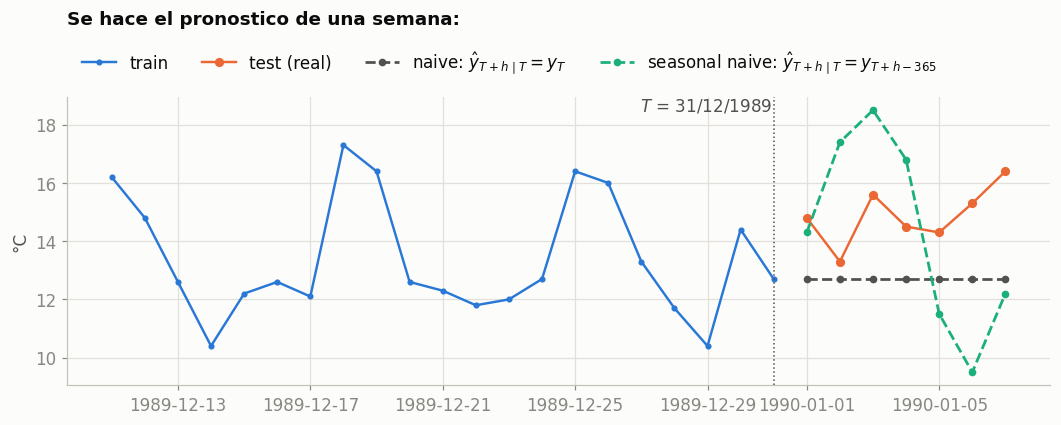

In [49]:
pred_naive = pd.Series(temp[T], index=test_7.index) # y_T para todo h

fig, ax = plt.subplots(figsize=(10, 4))
cola = entrenamiento[T - 20*D:] # los últimos 21 días del train
ax.plot(cola.index, cola, color=AZUL, lw=1.6, marker="o", ms=3, label="train")
ax.plot(test_7.index, test_7, color=NARANJA, lw=1.6, marker="o", ms=5, label="test (real)")
ax.plot(pred_naive, color=TINTA2, lw=1.8, ls="--", marker="o", ms=4,
        label=r"naive: $\hat{y}_{T+h\mid T} = y_T$")
ax.plot(pred_snaive, color=AQUA, lw=1.8, ls="--", marker="o", ms=4,
        label=r"seasonal naive: $\hat{y}_{T+h\mid T} = y_{T+h-365}$")
ax.axvline(T, color=TINTA2, lw=1, ls=":")
ax.annotate("$T$ = 31/12/1989 ", (T, ax.get_ylim()[1]), ha="right", va="top", color=TINTA2)
ax.set_ylabel("°C")
ax.set_title("Se hace el pronostico de una semana: \n", loc="left", pad=34)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncols=4)
fig.tight_layout(); plt.show()

In [50]:
# reutilizamos mae() y rmse() de la sección 1
escala = entrenamiento.diff().abs().mean()   # MAE del naive DENTRO del train → escala del MASE
print(f"escala del MASE (calculada en el entrenamiento): {escala:.2f} °C")
print()
print(f"naive:           MAE = {mae(test_7, pred_naive):.2f}   "
      f"RMSE = {rmse(test_7, pred_naive):.2f}   "
      f"MASE = {mae(test_7, pred_naive) / escala:.2f}")
print(f"seasonal naive:  MAE = {mae(test_7, pred_snaive):.2f}   "
      f"RMSE = {rmse(test_7, pred_snaive):.2f}   "
      f"MASE = {mae(test_7, pred_snaive) / escala:.2f}")

escala del MASE (calculada en el entrenamiento): 2.15 °C

naive:           MAE = 2.19   RMSE = 2.37   MASE = 1.02
seasonal naive:  MAE = 3.23   RMSE = 3.58   MASE = 1.51


## Valudacion curzada con series de tiempo

quedó una duda abierta: un test de 7 días es una **muestra chica** — la
conclusión de un solo corte puede ser mérito o puede ser suerte. Podemos usar lo que se llama **Walk-forward**, es repetir el train-test muchas veces, **moviendo el corte hacia adelante**.

El método

Cada repetición es un train-test común y corriente. En el corte $i$ el origen es $o_i$:

$$\text{entrenamiento}_i = \{y_1, \ldots, y_{o_i}\}
\qquad\qquad
\text{test}_i = \{y_{o_i+1}, \ldots, y_{o_i+7}\}$$

con $o_1 = T = $ 31/12/1989 y $o_{i+1} = o_i + 7$: **el origen camina una semana por vez** —
de ahí el nombre. La única regla: el origen **siempre avanza**, nunca se mezcla — el
entrenamiento jamás contiene días posteriores a su test.

Con 52 cortes cubrimos todo 1990:

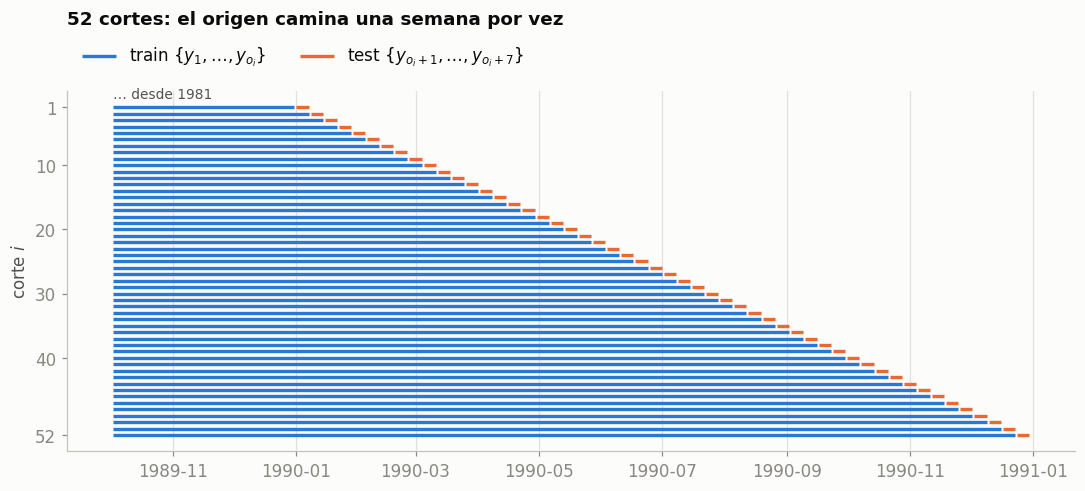

In [51]:
# Tomo el corte T

T = pd.Timestamp("1989-12-31")
origenes = pd.date_range(T, periods=52, freq="7D")   # o_1 = T, y avanza de a 7 días

fig, ax = plt.subplots(figsize=(10, 4.6))
for i, o in enumerate(origenes, start=1):
    ax.hlines(i, T - 90*D, o, color=AZUL, lw=2.2,
              label=r"train $\{y_1, \ldots, y_{o_i}\}$" if i == 1 else None)
    ax.hlines(i, o + D, o + 7*D, color=NARANJA, lw=2.2,
              label=r"test $\{y_{o_i+1}, \ldots, y_{o_i+7}\}$" if i == 1 else None)
ax.annotate("… desde 1981 \n", (T - 90*D, 0.3), color=TINTA2, fontsize=9, va="center")
ax.set_yticks([1, 10, 20, 30, 40, 52]); ax.set_ylabel("corte $i$")
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_title("52 cortes: el origen camina una semana por vez \n", loc="left", pad=30)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncols=2)
fig.tight_layout(); plt.show()

## Dos cortes

Antes de correr los 52, miremos los dos primeros. En cada corte se repite **exactamente la
misma receta** —predecir la semana y medirla— con el origen desplazado 7 días. Los métodos
van a seguir siendo el **naive** (repetir $y_{o_i}$) y el **seasonal naive** (copiar la
misma semana del año anterior).

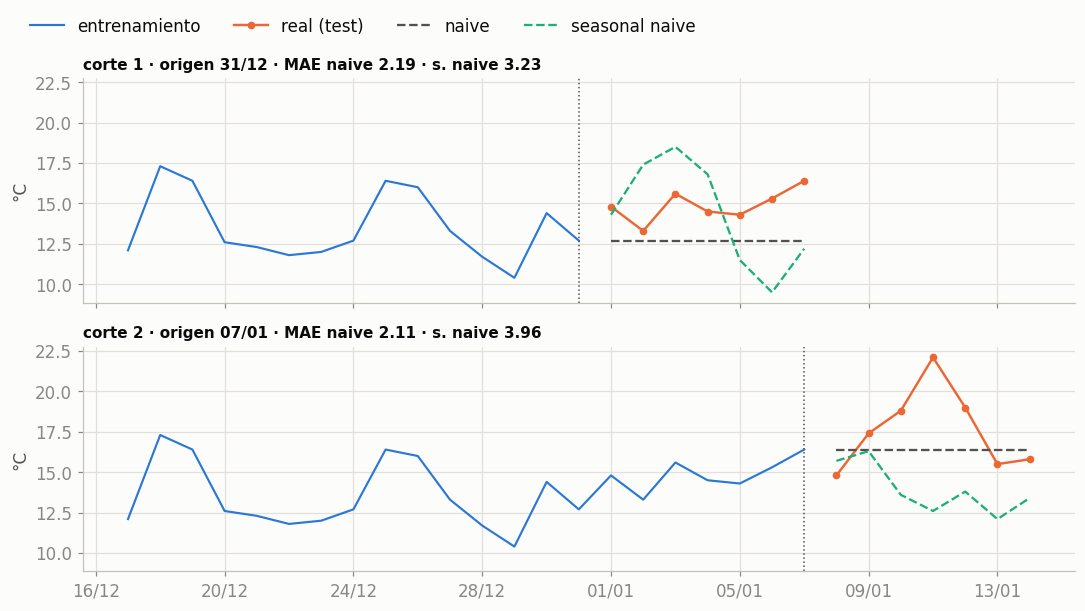

In [52]:
import matplotlib.dates as mdates

ini = origenes[0] - 14*D                       # borde izquierdo común: los dos ejes alineados
fig, axes = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True, sharey=True)
for ax, (i, o) in zip(axes, enumerate(origenes[:2], start=1)):
    test_o = temp[o + D : o + 7*D]
    pred_n = pd.Series(temp[o], index=test_o.index)                             # naive
    pred_s = pd.Series(temp[test_o.index - m*D].to_numpy(), index=test_o.index) # seasonal naive
    cola = temp[ini : o]
    ax.plot(cola.index, cola, color=AZUL, lw=1.4, label="entrenamiento")
    ax.plot(test_o.index, test_o, color=NARANJA, lw=1.6, marker="o", ms=4, label="real (test)")
    ax.plot(pred_n, color=TINTA2, lw=1.5, ls="--", label="naive")
    ax.plot(pred_s, color=AQUA, lw=1.5, ls="--", label="seasonal naive")
    ax.axvline(o, color=TINTA2, lw=1, ls=":")
    ax.set_ylabel("°C")
    ax.set_title(f"corte {i} · origen {o:%d/%m} · "
                 f"MAE naive {mae(test_o, pred_n):.2f} · s. naive {mae(test_o, pred_s):.2f}",
                 loc="left", fontsize=10)
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=4))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.02, 1.0), ncols=4)
fig.tight_layout(rect=(0, 0, 1, 0.94)) ; plt.show()

## Cómo se calcula la métrica

Cada corte deja **7 errores absolutos** — uno por horizonte $h = 1, \ldots, 7$. Apilando los
52 cortes queda una **matriz de 52 filas × 7 columnas**, y todas las métricas del
walk-forward son promedios de esa matriz:

| promedio de… | qué responde |
|---|---|
| la **fila** $i$ | el MAE del corte $i$ (lo que anotamos en los títulos de arriba) |
| la **columna** $h$ | el MAE del horizonte $h$: ¿cuánto cuesta pronosticar más lejos? |
| **toda la matriz** | el MAE global del método |

$$\text{MAE}(h) \;=\; \frac{1}{52}\sum_{i=1}^{52} \bigl|\, y_{o_i+h} - \hat{y}_{o_i+h \mid o_i} \bigr|$$

In [53]:
filas_naive, filas_snaive = [], []
for o in origenes:
    test_o = temp[o + D : o + 7*D]
    filas_naive.append((test_o - temp[o]).abs().to_numpy())
    filas_snaive.append(np.abs(test_o.to_numpy() - temp[test_o.index - m*D].to_numpy()))

err_naive  = pd.DataFrame(filas_naive,  columns=range(1, 8))   # 52 cortes × 7 horizontes
err_snaive = pd.DataFrame(filas_snaive, columns=range(1, 8))
err_naive.index.name = "corte"; err_naive.columns.name = "h"
err_naive.round(1).head(3)

h,1,2,3,4,5,6,7
corte,,,,,,,
0,2.1,0.6,2.9,1.8,1.6,2.6,3.7
1,1.6,1.0,2.4,5.7,2.6,0.9,0.6
2,1.1,5.1,4.3,0.8,1.3,1.3,2.5


## La métrica en el horizonte

Se calcula el promedio de cada **columna**. Promediando 52 cortes,
se tiene:

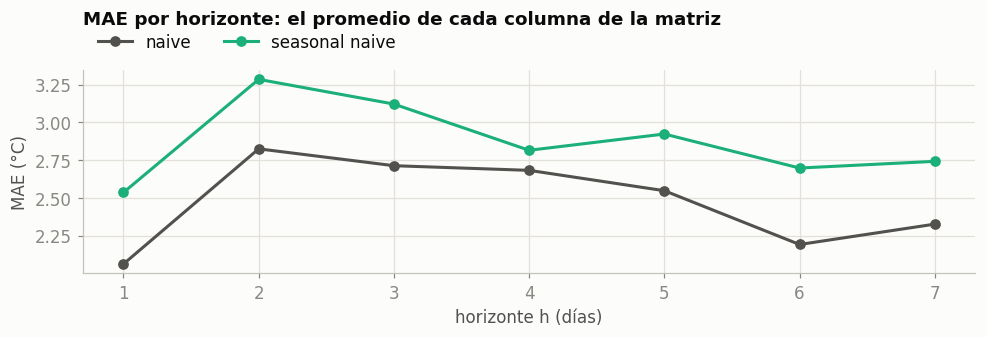

In [54]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(err_naive.mean(), color=TINTA2, lw=2, marker="o", label="naive")
ax.plot(err_snaive.mean(), color=AQUA, lw=2, marker="o", label="seasonal naive")
ax.set_xlabel("horizonte h (días)"); ax.set_ylabel("MAE (°C)")
ax.set_title("MAE por horizonte: el promedio de cada columna de la matriz", loc="left", pad=30)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncols=2)
fig.tight_layout(); plt.show()

Dos lecturas:

- El naive es **más preciso en $h=1$** (2,06 °C) y empeora al alejarse: su única ventaja es
  la persistencia del clima, y se agota en un par de días.
- El **seasonal naive pierde en los 7 horizontes**: el ruido que copia del año anterior le
  cuesta en todos lados, no fue mala suerte de una semana.

## 5 · El cálculo final

El MAE global es el promedio de **toda la matriz** — y da lo mismo promediar las celdas, los
cortes o los horizontes:

In [55]:
for nombre, err in [("naive", err_naive), ("seasonal naive", err_snaive)]:
    print(f"{nombre}:")
    print(f"  promedio de las 52 × 7 celdas  = {err.to_numpy().mean():.2f} °C")
    print(f"  promedio de los 52 cortes      = {err.mean(axis=1).mean():.2f} °C")
    print(f"  promedio de los 7 horizontes   = {err.mean(axis=0).mean():.2f} °C")
    print()

naive:
  promedio de las 52 × 7 celdas  = 2.48 °C
  promedio de los 52 cortes      = 2.48 °C
  promedio de los 7 horizontes   = 2.48 °C

seasonal naive:
  promedio de las 52 × 7 celdas  = 2.87 °C
  promedio de los 52 cortes      = 2.87 °C
  promedio de los 7 horizontes   = 2.87 °C



### En resumen

1. **Walk-forward** = repetir el train-test desplazando el origen hacia adelante. El
   entrenamiento nunca contiene días posteriores a su test.
2. Todos los números salen de una sola estructura: la **matriz cortes × horizontes** de
   errores absolutos. Fila → un corte; columna → un horizonte; todo → la métrica final.
3. El veredicto que un corte no podía dar: **naive 2,48 °C contra seasonal naive 2,87 °C**,
   consistente en los 7 horizontes. Repetir separa el mérito de la suerte.

## 1 · Métodos basados en arboles

**Decision Tree (Regression)** — divide el espacio de los predictores en regiones
mediante cortes binarios sucesivos. En cada región, la predicción se obtiene a partir
de las observaciones de entrenamiento que quedaron agrupadas allí.

**Random Forest** — combina múltiples árboles entrenados en paralelo. Cada árbol se
entrena sobre una muestra diferente de los datos mediante **Bootstrap Sampling**
y, en cada división, considera un subconjunto aleatorio de variables
(**Random Feature Selection**). Finalmente, las predicciones de los árboles se combinan,
generalmente mediante un promedio en problemas de regresión.

**Boosting** — construye árboles de manera secuencial. Cada nuevo árbol intenta mejorar
los errores del modelo acumulado hasta ese momento. La contribución de cada árbol se
controla mediante un parámetro denominado **Learning Rate** o **Shrinkage**.

Algunos parámetros importantes son:

- **Number of Trees**: cantidad de árboles utilizados.
- **Learning Rate**: cuánto aporta cada nuevo árbol al modelo.
- **Tree Depth / Maximum Depth**: complejidad de cada árbol.
- **Number of Features / Max Features**: cantidad de variables consideradas en cada división.
- **Minimum Samples per Leaf**: cantidad mínima de observaciones necesarias en una hoja.

Para trabajar con series temporales, una vez transformada la serie en una tabla de
variables predictoras (**Features**) y una variable objetivo (**Target**), estos métodos
pueden utilizarse como modelos estándar de **Supervised Regression**.

Implementaciones en bibliotecas que son muy utilizadas:

Bibliotecas de gradient boosting con árboles: **XGBoost** y **LightGBM**. Ambas ofrecen interfaces compatibles con modelos de regresión y pueden emplearse en forecasting mediante variables de lag y calendario.

## 2 · Chronos

**Chronos** — modelo de forecasting basado en **Transformers** que representa una serie
temporal como una secuencia de valores discretizados, de manera similar a cómo un
**Language Model** procesa una secuencia de tokens.

**Architecture** — utiliza una arquitectura **Encoder-Decoder Transformer** basada en
la familia **T5**.

### Funcionamiento del Chronos original

1. **Scaling** — la serie temporal se normaliza mediante un procedimiento de
   **Mean Scaling**.

2. **Tokenization / Quantization** — los valores continuos de la serie se transforman
   en valores discretos pertenecientes a un vocabulario finito. Cada valor discretizado
   se representa mediante un **Token**.

3. **Training** — el modelo aprende a predecir el siguiente token utilizando
   **Cross-Entropy Loss** sobre grandes colecciones de series temporales.

4. **Autoregressive Forecasting** — durante la inferencia, el modelo genera los valores
   futuros de manera secuencial, utilizando las predicciones anteriores como parte del
   contexto.

5. **Probabilistic Forecasting** — pueden generarse múltiples trayectorias futuras
   mediante **Sampling**. A partir de ellas pueden obtenerse estadísticas como
   **Quantiles**, intervalos y distribuciones predictivas.

---

### Chronos-Bolt

**Chronos-Bolt** es una variante optimizada para realizar forecasting de manera más
eficiente.

En lugar de procesar cada observación individualmente, utiliza **Patch-Based
Representation**, agrupando múltiples observaciones consecutivas en bloques o
**Patches**.

Además, utiliza **Direct Multi-Step Forecasting**: genera múltiples pasos futuros
directamente en una única inferencia, en lugar de producirlos de manera autoregresiva.

Conceptos principales:

- **Patching**: agrupación de observaciones consecutivas.
- **Direct Multi-Step Forecasting**: predicción simultánea de varios pasos futuros.
- **Quantile Forecasting**: predicción directa de diferentes cuantiles de la distribución futura.
- **Context Window**: conjunto de observaciones pasadas utilizadas como entrada.
- **Prediction Horizon**: cantidad de pasos futuros que se desea pronosticar.

Chronos-Bolt está disponible en distintos tamaños de modelo:

- **Tiny**: 9M parameters.
- **Mini**: 21M parameters.
- **Small**: 48M parameters.
- **Base**: 205M parameters.

Para nuestro caso utilizamos **Chronos-Bolt Tiny**.

---

### Zero-Shot Forecasting

Chronos puede utilizarse mediante **Zero-Shot Forecasting**.

Esto significa que el modelo puede generar un pronóstico sobre una serie temporal que
no fue utilizada específicamente durante su entrenamiento, aprovechando patrones
aprendidos durante el **Pretraining**.

Por lo tanto, no es necesario realizar un nuevo proceso de entrenamiento mediante
`.fit()` para cada serie.

El flujo básico es:

**Historical Context → Pretrained Model → Forecast**

En este caso, las observaciones históricas de la serie funcionan como **Context** y el
modelo genera directamente el **Forecast** para el horizonte solicitado.


In [56]:
!pip install -q chronos-forecasting

## 3 · Los datos: demanda eléctrica horaria

**PJM Hourly Energy Consumption** — demanda horaria en megawatts de la red PJM (este de
EE.UU.), del dataset público [PJM Hourly Energy
(Kaggle)](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption).

Pronosticar la demanda eléctrica es un problema real y cotidiano: los operadores de red lo
resuelven **cada hora**, para decidir cuántas centrales encender.

Usamos la ventana del **13/3 al 4/11 de 2017** a propósito: queda **entre los dos cambios de
horario** de EE.UU. — en las transiciones el dataset original tiene una hora duplicada y una
faltante, y así trabajamos con una serie limpia y regular.

In [57]:
!mkdir -p datos figuras
!curl -sL -o /content/datos/PJME_hourly.csv https://raw.githubusercontent.com/panambY/Hourly_Energy_Consumption/master/data/PJME_hourly.csv
!ls -lh /content/datos/PJME_hourly.csv

-rw-r--r-- 1 root root 3.9M Sep  2 13:39 /content/datos/PJME_hourly.csv


In [58]:
crudo = pd.read_csv("datos/PJME_hourly.csv", parse_dates=["Datetime"])
serie = (pd.Series(crudo["PJME_MW"].to_numpy(), index=crudo["Datetime"])
         .sort_index()
         .loc["2017-03-13":"2017-11-04"])       # entre los dos cambios de horario
print(f"{len(serie)} horas   {serie.index.min()} → {serie.index.max()}")
print(f"demanda media: {serie.mean():.0f} MW   |   mín {serie.min():.0f} — máx {serie.max():.0f}")

5688 horas   2017-03-13 00:00:00 → 2017-11-04 23:00:00
demanda media: 30417 MW   |   mín 19255 — máx 55218


### Mirar la serie

Las últimas tres semanas. Fíjense en las **dos escalas a la vez**: cada día es una montaña
—valle de madrugada, pico a la tarde— y los fines de semana (en naranja) las montañas son
más bajas. Esa **estructura en capas** —ciclo diario + ciclo semanal + persistencia— es lo
que los modelos van a intentar capturar.

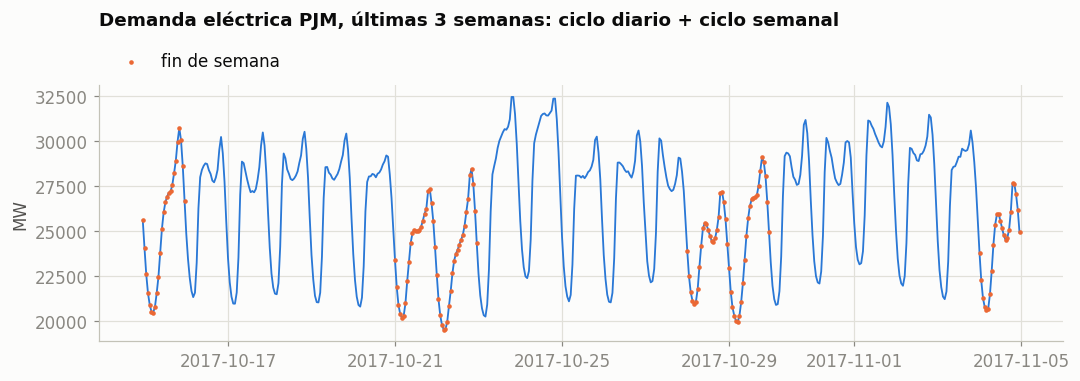

In [59]:
zoom = serie[serie.index >= serie.index.max() - pd.Timedelta(days=21)]

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(zoom, color=AZUL, lw=1.2)
finde = zoom[zoom.index.dayofweek >= 5]
ax.scatter(finde.index, finde, s=4, color=NARANJA, zorder=3, label="fin de semana")
ax.set_ylabel("MW")
ax.set_title("Demanda eléctrica PJM, últimas 3 semanas: ciclo diario + ciclo semanal\n",
             loc="left", pad=26)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0))
fig.tight_layout(); plt.show()

## El experimento: pronosticar las próximas 24 horas

Vamos a seguir la misma metodología que vimos anteriormente, tomando los datasets:

$$\text{train} = \{y_1, \ldots, y_T\}
\qquad\qquad
\text{test} = \{y_{T+1}, \ldots, y_{T+24}\} \;=\; \text{las próximas 24 horas}$$

Cortamos una semana antes del final de los datos: así después vamos a poder **repetir el
experimento 7 veces** (walk-forward) sin tocar el entrenamiento.

Vamos a tomar como **baseline**: el modelo naive (repetir $y_T$) y el seasonal naive (copiar la misma
hora de ayer). Si otro modelo no les gana, no está extrayendo nada.

In [60]:
hora = pd.Timedelta(hours=1)
H = 24
T = serie.index.max() - 7 * 24 * hora              # una semana antes del final

entrenamiento = serie[serie.index <= T]
test_24 = serie[T + hora : T + H * hora]

print(f"entrenamiento: {len(entrenamiento)} horas ({entrenamiento.index.min():%Y-%m-%d} → {T})")
print(f"test:          {len(test_24)} horas (el {test_24.index.min():%d/%m} de {test_24.index.min():%H:%M} a {test_24.index.max():%H:%M})")
print(f"y_T = {serie[T]:.0f} MW   ← la predicción del naive para las 24 horas")

entrenamiento: 5520 horas (2017-03-13 → 2017-10-28 23:00:00)
test:          24 horas (el 29/10 de 00:00 a 23:00)
y_T = 24320 MW   ← la predicción del naive para las 24 horas


In [61]:
X = pd.DataFrame({
    "lag_24":  serie.shift(24), # misma hora de ayer
    "lag_48":  serie.shift(48), # misma hora de anteayer
    "lag_168": serie.shift(168), # misma hora, semana pasada
    "hora":    serie.index.hour, # hora del dia
    "dow":     serie.index.dayofweek, # dia de la semana
}, index=serie.index)

X.loc[:T].tail(3)

,lag_24,lag_48,lag_168,hora,dow
Datetime,,,,,
2017-10-28 21:00:00,28316.0,29994.0,26578.0,21,5
2017-10-28 22:00:00,27246.0,28635.0,25555.0,22,5
2017-10-28 23:00:00,25616.0,26612.0,24126.0,23,5


In [62]:
X_train = X.loc[:T].dropna()
y_train = serie.loc[X_train.index]

print(f"{len(X_train)} horas de entrenamiento, hasta {T}")

5352 horas de entrenamiento, hasta 2017-10-28 23:00:00


## Entrenamiento de RandomForest

In [63]:
# Random Forest: 100 árboles en paralelo sobre muestras bootstrap
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1).fit(X_train, y_train)

## Entrenamiento de Gradient Boosting

In [64]:
# Gradient Boosting: árboles chicos en secuencia, cada uno corrige al anterior
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=0).fit(X_train, y_train)

## Uso de Chronos

**Chronos ya viene entrenado**: no hay `.fit()`. Le damos la historia hasta el origen
como contexto y le pedimos 24 pasos. Definimos `predecir(o)`, que junta los **cuatro
métodos** — la vara (naive), los dos árboles y Chronos — pronosticando las 24 horas que
siguen a cualquier origen `o`:

In [65]:
import torch
from chronos import BaseChronosPipeline

pipe = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-tiny",
                                           device_map="cpu", torch_dtype=torch.float32)
print("chronos-bolt-tiny cargado: 9M de parámetros, zero-shot")

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

chronos-bolt-tiny cargado: 9M de parámetros, zero-shot


Y ahora sí: `predecir(o)` junta los **cuatro métodos** — la vara (naive), los dos árboles
y Chronos — pronosticando las 24 horas que siguen a cualquier origen `o`:

In [66]:
modelos = {"random forest": rf, "gradient boosting": gb}

def predecir(o):
    """Los cuatro métodos pronosticando las 24 horas que siguen al origen o."""
    idx = pd.date_range(o + hora, o + H * hora, freq="h")
    preds = {"naive": pd.Series(serie[o], index=idx)}
    for nombre, m in modelos.items():
        preds[nombre] = pd.Series(m.predict(X.loc[idx]), index=idx)
    q, _ = pipe.predict_quantiles(torch.tensor(serie[serie.index <= o].to_numpy()[-2048:]),
                                  prediction_length=H, quantile_levels=[0.5])
    preds["chronos-bolt-tiny"] = pd.Series(q[0, :, 0].numpy(), index=idx)
    return preds

preds_1 = predecir(T)
print("listo: cuatro pronósticos para las 24 horas que siguen al corte")

listo: cuatro pronósticos para las 24 horas que siguen al corte


# Resultados

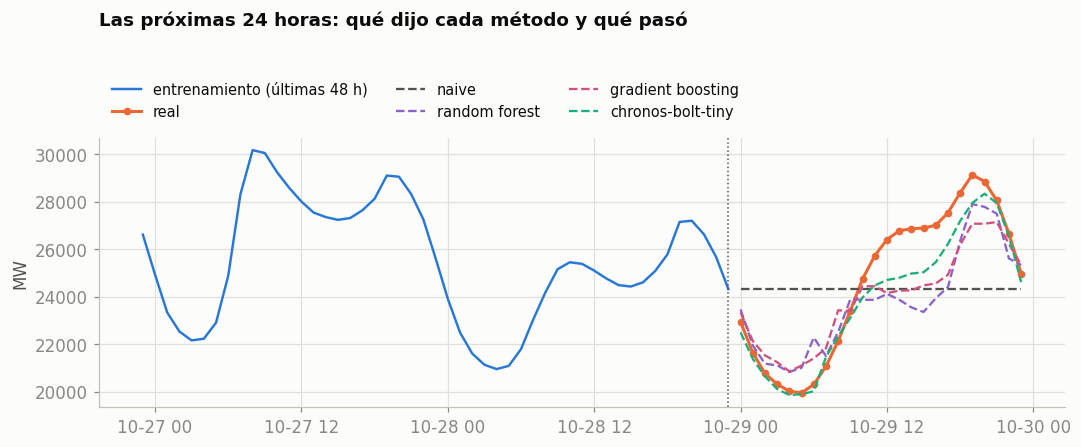

In [67]:
colores = {"naive": TINTA2, "random forest": VIOLETA,
           "gradient boosting": ROSA, "chronos-bolt-tiny": AQUA}

fig, ax = plt.subplots(figsize=(10, 4.2))
cola = entrenamiento[T - 48 * hora:]
ax.plot(cola, color=AZUL, lw=1.6, label="entrenamiento (últimas 48 h)")
ax.plot(test_24, color=NARANJA, lw=2, marker="o", ms=4, label="real")
for nombre, p in preds_1.items():
    ax.plot(p, color=colores[nombre], lw=1.5, ls="--", label=nombre)
ax.axvline(T, color=TINTA2, lw=1, ls=":")
ax.set_ylabel("MW")
ax.set_title("Las próximas 24 horas: qué dijo cada método y qué pasó", loc="left", pad=74)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncols=3, fontsize=9.5)
fig.tight_layout(); plt.show()

In [68]:
escala = entrenamiento.diff().abs().mean()      # error del naive a 1 hora DENTRO del train
print(f"escala del MASE (train): {escala:.0f} MW")
print()
for nombre, p in preds_1.items():
    print(f"{nombre:18s} MAE = {mae(test_24, p):6.0f} MW   "
          f"RMSE = {rmse(test_24, p):6.0f}   MASE = {mae(test_24, p) / escala:.2f}")

escala del MASE (train): 1084 MW

naive              MAE =   2838 MW   RMSE =   3098   MASE = 2.62
random forest      MAE =   1434 MW   RMSE =   1782   MASE = 1.32
gradient boosting  MAE =   1328 MW   RMSE =   1570   MASE = 1.23
chronos-bolt-tiny  MAE =    758 MW   RMSE =   1001   MASE = 0.70


## Walk-forward: repetir 7 veces (reentrenando)

Un corte solo puede engañar (parte 1.5). Repetimos el ritual completo en los **7 días de la
última semana**, corriendo el origen de a 24 horas: en cada origen el train **crece** con
todo lo observado hasta ahí, los árboles se **reentrenan**, y se pronostican las 24 horas
siguientes.

(Chronos no tiene `.fit()`: su equivalente es recibir el contexto hasta el origen, que
`predecir` ya hace. Y el naive siempre usa el último valor del origen.)

In [69]:
origenes = pd.date_range(T, periods=7, freq="24h")

pronosticos = {}                                  # día → {método: pronóstico de 24 h}
for origen in origenes:
    Xo = X.loc[:origen].dropna()                  # el train crece hasta el origen
    rf.fit(Xo, serie.loc[Xo.index])               # reentrenar con todo lo visto hasta o
    gb.fit(Xo, serie.loc[Xo.index])
    pronosticos[f"{origen + hora:%d/%m}"] = predecir(origen)

print("pronósticos de los 7 días guardados")

pronósticos de los 7 días guardados


In [70]:
def tabla(pronos, metrica):
    """Una tabla días × métodos para la métrica dada."""
    return pd.DataFrame({dia: {nombre: metrica(serie[p.index], p)
                               for nombre, p in preds.items()}
                         for dia, preds in pronos.items()}).T

res_mae, res_rmse = tabla(pronosticos, mae), tabla(pronosticos, rmse)
res_mase = res_mae / escala                       # el MASE es solo el MAE reescalado

pd.concat({"MAE (MW)": res_mae.round(0), "RMSE (MW)": res_rmse.round(0),
           "MASE": res_mase.round(2)}, axis=1)

MAE (MW)                                                   RMSE (MW)  \
         naive random forest gradient boosting chronos-bolt-tiny     naive   
29/10   2838.0        1434.0            1328.0             758.0    3098.0   
30/10   3582.0         723.0            1154.0             785.0    3789.0   
31/10   2490.0         591.0             939.0             995.0    2766.0   
01/11   3102.0        1462.0            1018.0            1650.0    3283.0   
02/11   2865.0        1820.0            1113.0             208.0    3116.0   
03/11   2892.0         515.0             827.0             327.0    3170.0   
04/11   1874.0         598.0             665.0            1146.0    2496.0   

                                                         MASE                \
      random forest gradient boosting chronos-bolt-tiny naive random forest   
29/10        1782.0            1570.0            1001.0  2.62          1.32   
30/10         930.0            1467.0            1043.0  3.30          0.67   
31/10         696.0            1089.0            1089.0  2.30          0.55   
01/11        1664.0            1111.0            1773.0  2.86          1.35   
02/11        2411.0            1223.0             256.0  2.64          1.68   
03/11         643.0             942.0             503.0  2.67          0.48   
04/11         930.0             904.0            1397.0  1.73          0.55   

                                           
      gradient boosting chronos-bolt-tiny  
29/10              1.23              0.70  
30/10              1.07              0.72  
31/10              0.87              0.92  
01/11              0.94              1.52  
02/11              1.03              0.19  
03/11              0.76              0.30  
04/11              0.61              1.06

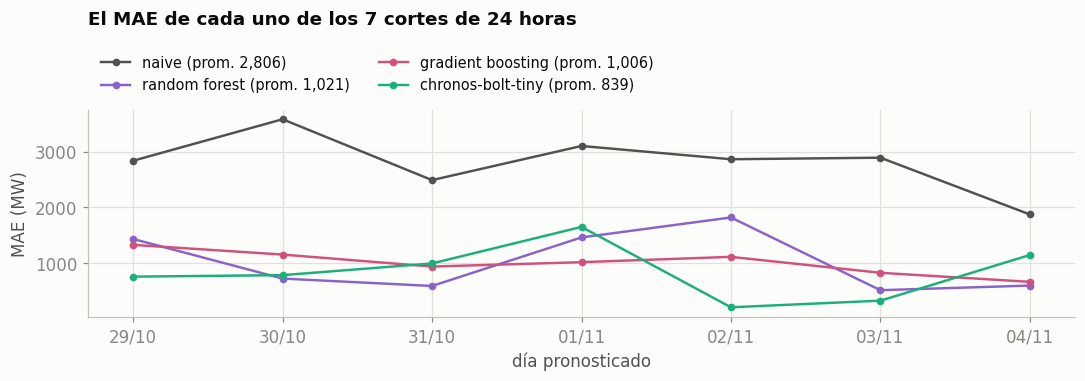

promedio de los 7 cortes:
  naive              MAE =   2806 MW   RMSE =   3103   MASE = 2.59   (+0% vs naive)
  random forest      MAE =   1021 MW   RMSE =   1294   MASE = 0.94   (+64% vs naive)
  gradient boosting  MAE =   1006 MW   RMSE =   1187   MASE = 0.93   (+64% vs naive)
  chronos-bolt-tiny  MAE =    839 MW   RMSE =   1009   MASE = 0.77   (+70% vs naive)


In [71]:
fig, ax = plt.subplots(figsize=(10, 3.6))
for nombre in res_mae.columns:
    ax.plot(res_mae.index, res_mae[nombre], color=colores[nombre], lw=1.6, marker="o", ms=4,
            label=f"{nombre} (prom. {res_mae[nombre].mean():,.0f})")
ax.set_ylabel("MAE (MW)"); ax.set_xlabel("día pronosticado")
ax.set_title("El MAE de cada uno de los 7 cortes de 24 horas", loc="left", pad=56)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncols=2, fontsize=9.5)
fig.tight_layout(); plt.show()

base = res_mae["naive"].mean()
print("promedio de los 7 cortes:")
for nombre in res_mae.columns:
    v = res_mae[nombre].mean()
    print(f"  {nombre:18s} MAE = {v:6.0f} MW   RMSE = {res_rmse[nombre].mean():6.0f}   "
          f"MASE = {res_mase[nombre].mean():.2f}   ({100 * (base - v) / base:+.0f}% vs naive)")

## Walk-forward: repetir 7 veces (sin reentrenar)

Un corte solo puede engañar (parte 1.5). Repetimos el experimento en los **7 días de la
última semana** — los modelos ya están entrenados, solo movemos el origen y volvemos a
predecir y medir:

In [72]:
rf.fit(X_train, y_train) # ← volver al modelo entrenado SOLO hasta T
gb.fit(X_train, y_train)

pronosticos_fijo = {} # modelo fijo: ningún fit dentro del bucle
for origen in origenes:
    pronosticos_fijo[f"{origen + hora:%d/%m}"] = predecir(origen)

fijo_mae, fijo_rmse = tabla(pronosticos_fijo, mae), tabla(pronosticos_fijo, rmse)
fijo_mase = fijo_mae / escala

pd.concat({"MAE (MW)": fijo_mae.round(0), "RMSE (MW)": fijo_rmse.round(0),
           "MASE": fijo_mase.round(2)}, axis=1)

origenes = pd.date_range(T, periods=7, freq="24h")

res = pd.DataFrame({o: {nombre: mae(serie[p.index], p) for nombre, p in predecir(o).items()}
                    for o in origenes}).T
res.index = [f"{o + hora:%d/%m}" for o in origenes]
res.round(0)

,naive,random forest,gradient boosting,chronos-bolt-tiny
29/10,2838.0,1434.0,1328.0,758.0
30/10,3582.0,716.0,1107.0,785.0
31/10,2490.0,546.0,897.0,995.0
01/11,3102.0,1468.0,969.0,1650.0
02/11,2865.0,1787.0,1209.0,208.0
03/11,2892.0,516.0,759.0,327.0
04/11,1874.0,562.0,664.0,1146.0


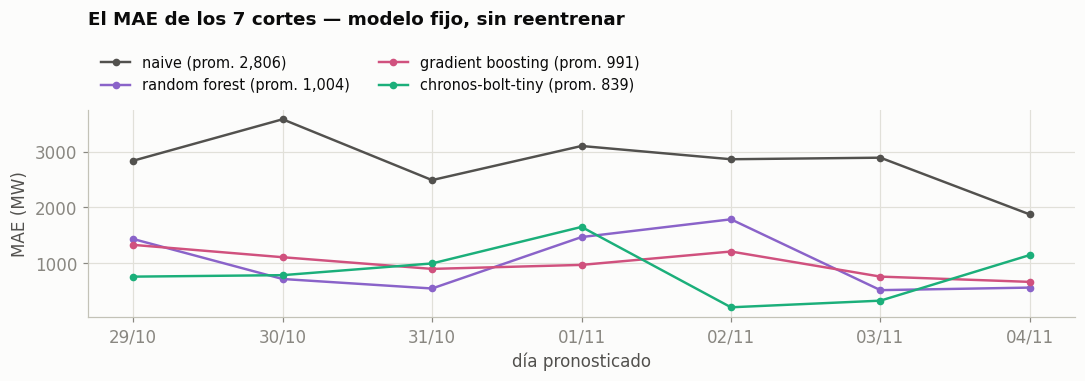

promedio de los 7 cortes (modelo fijo):
  naive              MAE =   2806 MW   RMSE =   3103   MASE = 2.59   (+0% vs naive)
  random forest      MAE =   1004 MW   RMSE =   1263   MASE = 0.93   (+64% vs naive)
  gradient boosting  MAE =    991 MW   RMSE =   1177   MASE = 0.91   (+65% vs naive)
  chronos-bolt-tiny  MAE =    839 MW   RMSE =   1009   MASE = 0.77   (+70% vs naive)


In [73]:
fig, ax = plt.subplots(figsize=(10, 3.6))
for nombre in fijo_mae.columns:
    ax.plot(fijo_mae.index, fijo_mae[nombre], color=colores[nombre], lw=1.6, marker="o", ms=4,
            label=f"{nombre} (prom. {fijo_mae[nombre].mean():,.0f})")
ax.set_ylabel("MAE (MW)"); ax.set_xlabel("día pronosticado")
ax.set_title("El MAE de los 7 cortes — modelo fijo, sin reentrenar", loc="left", pad=56)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncols=2, fontsize=9.5)
fig.tight_layout(); plt.show()

base = fijo_mae["naive"].mean()
print("promedio de los 7 cortes (modelo fijo):")
for nombre in fijo_mae.columns:
    v = fijo_mae[nombre].mean()
    print(f"  {nombre:18s} MAE = {v:6.0f} MW   RMSE = {fijo_rmse[nombre].mean():6.0f}   "
          f"MASE = {fijo_mase[nombre].mean():.2f}   ({100 * (base - v) / base:+.0f}% vs naive)")

> **💡 Nota — ¿hacía falta reentrenar 7 veces?** Acá reentrenamos en cada origen porque es
> el walk-forward que vimos en la teoría. Pero existe una variante muy común en la práctica:
> **modelo fijo, origen móvil** — entrenar una sola vez hasta $T$ y en cada corte solo mover
> el origen, recalculando los features. Se usa cuando reentrenar es caro (modelos pesados,
> miles de series, pipelines lentos).
> Probamos las dos y acá dan resultados similares dado que **Los datos nuevos son muy pocos**: cada corte agrega 24 horas a un train de ~5.400

# Conclusión

> 📖 *"Un buen pronóstico captura los patrones y relaciones genuinos de los datos
> históricos, pero no replica eventos del pasado que no van a volver a ocurrir."*
> — Hyndman & Athanasopoulos, **Forecasting: Principles and Practice**
> ([otexts.com/fpppy](https://otexts.com/fpppy/))

Esa frase resume todo el recorrido. **El valor de un pronóstico no está en la sofisticación
del modelo sino en cuánta estructura genuina tenga la serie** — y en que el modelo la
extraiga sin inventar la que no existe.

La demanda eléctrica lo mostró con claridad: tenía **estructura en capas** (ciclo diario +
ciclo semanal + persistencia) y datos abundantes, y por eso *todos* los modelos aplastaron
al naive (~64–70% menos error). Los tres enfoques son en realidad un espectro de **dónde
vive el conocimiento de esa estructura**:

- **Naive** — no asume estructura: repite el último valor. Es la **vara**: el libro insiste
  en que ningún método merece usarse si no le gana a los métodos simples de referencia.
- **Árboles** — la estructura se la entregamos **nosotros, a mano**, en la tabla de
  features: `lag_24` (ciclo diario), `lag_168` (ciclo semanal), `hora`, `dow`. El modelo
  solo aprende la relación features → demanda; puede ignorar el tiempo porque la tabla ya
  lo respetó por él.
- **Chronos** — la estructura viene **aprendida del preentrenamiento** sobre ~100 mil
  millones de observaciones: recibe la serie cruda como contexto, sin features ni `.fit()`,
  y reconoce los ciclos porque los vio en millones de series parecidas.

Y nada de esto se puede *afirmar* sin el ritual de evaluación que el libro enseña: la única
evidencia válida es el error sobre datos que el modelo no vio, medido más de una vez.

## Resumen del recorrido

1. **Serie temporal**: observaciones ordenadas donde **el orden importa**. Vocabulario:
   lag, **tendencia** (largo plazo), **estacionalidad** (frecuencia fija y conocida),
   **ciclo** (frecuencia variable), ruido. La predictibilidad va a depender
   de la serie.
2. **Métricas**: la media del error mide sesgo, no magnitud (se cancela). **MAE** y
   **RMSE** en unidades reales; **MAPE** explota cerca de cero y exige un cero con
   significado; **MASE** divide por el error del naive *dentro del train* y permite
   comparar entre series.
3. **Train-test**: el corte es **por tiempo, nunca al azar**; todo (modelos, escala del
   MASE) se construye solo con el train; el test únicamente se toca para medir.
4. **Walk-forward**: repetir el train-test corriendo el origen hacia adelante — la matriz
   **cortes × horizontes** contiene todas las métricas (fila = un corte, columna = un
   horizonte, todo = la métrica global). Un solo corte puede ser suerte; repetir separa el
   mérito del azar.
5. **Dos variantes válidas** del walk-forward: reentrenar en cada origen (la forma
   canónica) o modelo fijo con origen móvil (común en la práctica). Acá dieron casi lo
   mismo resultado, porque los datos nuevos por corte son ínfimos y la
   información reciente ya entra por los lags.
6. **El veredicto en la demanda PJM** (promedio de 7 cortes de 24 horas): naive 2.806 MW →
   árboles ~1.000 MW (MASE ≈ 0,93) → **Chronos 839 MW (MASE 0,77, ~70% mejor que el
   naive)** — un error de ~3% de la demanda media, extraído de estructura que estaba en la
   serie.